# Week 6 Day 5 Lab
For the final lab, we'll cover Markov Chain Monte Carlo (MCMC). Recall that Monte Carlo is simply a method of estimating through lots and lots of random sampling. Similarly, MCMC depends on lots of random sampling. However, the *way* we sample is different.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

### Dependent State Random Sampling
Instead of randomly sampling each point **independently**, we make the next sample **depend** on what we just sampled previously. Much like your next move in chess might be random, your next move is very dependent on where the pieces are placed currently.

In [3]:
target = [0.01, 0.01, 0.01, 0.07, 0.9]

In [4]:
def mcmc(steps, target):
    distance = []
    n = len(target)                                   # number of options
    current = np.random.choice([i for i in range(n)])       # random current starting option
    
    samples = [current]
    for i in range(steps):
        proposal = np.random.choice([i for i in range(n)])      # choose a proposed next step
        a = min(1, target[proposal] / target[current])   # how good is the proposed step compared to current step?
        
        # if a is better than a uniform at random choice, move to the proposed step!
        if np.random.uniform(0,1) < a:              
            current = proposal                          
            currestimate = np.bincount(samples, minlength=len(target)) / len(samples)
            distance.append(abs(target-currestimate))                           # keep track of error
        
        # if a is worse than a uniform at random choice, stay where you are!
        else:
            currestimate = np.bincount(samples, minlength=len(target)) / len(samples)
            distance.append(abs(target-currestimate))                     # keep track of error
        samples.append(current)                                           # keep track of movement
    return np.array(samples), distance

In [5]:
samples, distance = mcmc(10000, target)
estimated = np.bincount(samples, minlength=len(target)) / len(samples)
print("Target distribution:   ", target)
print("MCMC estimate of the distribution:  ", estimated)

Target distribution:    [0.01, 0.01, 0.01, 0.07, 0.9]
MCMC estimate of the distribution:   [0.00959904 0.01039896 0.01029897 0.07339266 0.89631037]


Text(0, 0.5, 'Error')

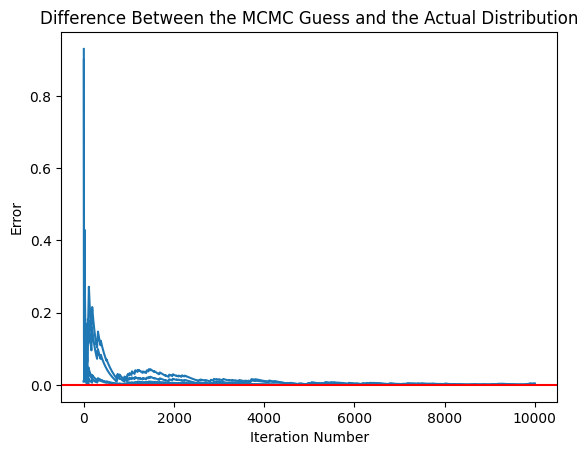

In [6]:
plt.plot([i for i in range(len(distance))], distance, c='C0')
plt.axhline(0, c='r')
plt.title('Difference Between the MCMC Guess and the Actual Distribution')
plt.xlabel('Iteration Number')
plt.ylabel('Error')

In [7]:
# computing region in circle

def region(x, y):
    if x**2+y**2<=1:     # in circle
        return 0
    if x>=0 and y>=0: # top left
        return 1
    elif x<0 and y>= 0: #top right
        return 2
    elif x<0 and y<0: #bottom left
        return 3
    else:                 # bottom right
        return 4


In [8]:
# mcmc sampling code

def mcmccircle(nsteps, target, step_size=0.2):
    x, y = 0.0, 0.0  # start at center
    samples = []

    for i in range(nsteps):
        xprop = x +np.random.normal(0, step_size) # propose a movement in x
        yprop = y +np.random.normal(0, step_size) # propose a movement in y
        if not (-1 <= xprop <= 1 and -1 <= yprop <= 1): # if outside, reject
            samples.append((x, y))
            continue
        rcurrent = region(x, y) # which region are you
        rprop = region(xprop, yprop) # which region is the propsed move
        alpha = min(1, target[rprop] / target[rcurrent]) # decide whether to move there

        if np.random.rand() < alpha:
            x, y = xprop, yprop

        samples.append((x, y))

    return np.array(samples)

In [9]:
# plotting code

def plotmcmc(samples):
    x = samples[:,0]
    y = samples[:,1]
    colors = []
    for i, j in zip(x, y):
        colors.append(region(i, j))
    plt.figure(figsize=(6,6))
    plt.scatter(x, y, c=colors, s=5)
    theta = np.linspace(0, 2*np.pi, 300)
    plt.plot(np.cos(theta), np.sin(theta))

    plt.title("MCMC on the Circle")
    plt.xlim([-1,1])
    plt.ylim([-1,1])
    plt.show()

In [10]:
target = [.9,.01,.01,.07,.01]
print(target)

[0.9, 0.01, 0.01, 0.07, 0.01]


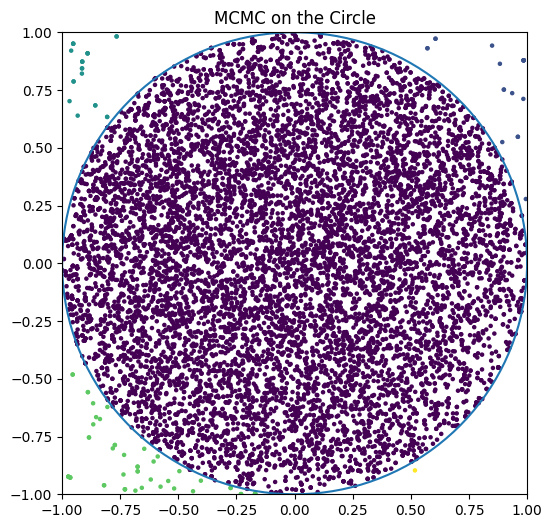

In [11]:
plotmcmc(mcmccircle(10000, target))

### Problem 1
Try running `mcmc` for 100, 1,000, and 10,000 steps to compare the estimates. What do you notices?

In [16]:
for steps in [100, 1000, 10000]:
    samples, distance = mcmc(steps, target)

    estimate = np.bincount(samples, minlength=len(target)) / len(samples)

    print("Steps: ", steps)
    print("Target:  ", target)
    print("Estimate:", estimate)
    print("Error:   ", np.abs(target - estimate))
    print("\n")

# Error decreases over more steps

Steps:  100
Target:   [0.9, 0.01, 0.01, 0.07, 0.01]
Estimate: [0.88118812 0.03960396 0.02970297 0.02970297 0.01980198]
Error:    [0.01881188 0.02960396 0.01970297 0.04029703 0.00980198]

Steps:  1000
Target:   [0.9, 0.01, 0.01, 0.07, 0.01]
Estimate: [0.87012987 0.01698302 0.01398601 0.08591409 0.01298701]
Error:    [0.02987013 0.00698302 0.00398601 0.01591409 0.00298701]

Steps:  10000
Target:   [0.9, 0.01, 0.01, 0.07, 0.01]
Estimate: [0.89091091 0.00839916 0.01009899 0.07969203 0.01089891]
Error:    [9.08909109e-03 1.60083992e-03 9.89901010e-05 9.69203080e-03
 8.98910109e-04]



### Problem 2
Write code that will run `mcmccircle()` until you have 1,000 points in the bottom right corner.

Total samples generated: 1438875
Bottom-right samples: 1000


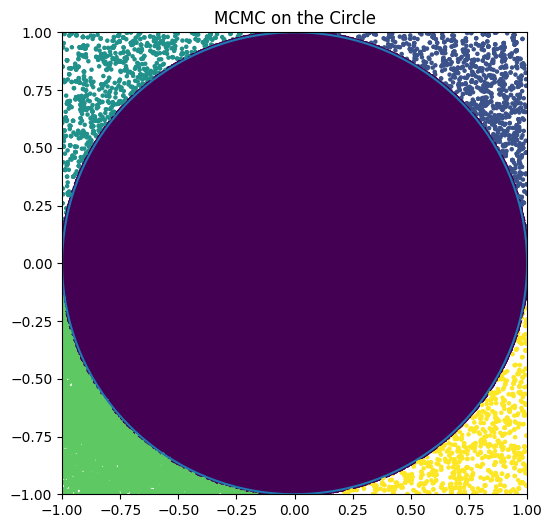

In [22]:
def mcmccircle_until(target, goal=1000, step_size=0.2):
    x, y = 0.0, 0.0
    samples = []
    bottom_right = 0

    while bottom_right < goal:
        xprop = x + np.random.normal(0, step_size)
        yprop = y + np.random.normal(0, step_size)

        if -1 <= xprop <= 1 and -1 <= yprop <= 1:
            rcurrent = region(x, y)
            rprop = region(xprop, yprop)

            alpha = min(1, target[rprop] / target[rcurrent])

            if np.random.rand() < alpha:
                x, y = xprop, yprop

        samples.append((x, y))

        if region(x, y) == 4:
            bottom_right += 1

    return np.array(samples)

samples = mcmccircle_until(target, goal=1000)

print("Total samples generated:", len(samples))
print("Bottom-right samples:", np.sum([region(x, y) == 4 for x, y in samples]))

plotmcmc(samples)

### Problem 3
Create your own `target` to be equal on all regions in `mcmc()`. Generate 100, 1,000, and 10,000 samples. Compare the averages of these runs. Do they converge?

In [25]:
target = np.array([0.2, 0.2, 0.2, 0.2, 0.2])

for steps in [100, 1000, 10000]:
    samples, _ = mcmc(steps, target)

    estimate = np.bincount(samples, minlength=len(target)) / len(samples)

    print("Steps", steps)
    print("Target:  ", target)
    print("Estimate:", estimate)
    print("Average:", np.mean(estimate))
    print("\n")

# They probably converge but there looks like there is floating point error.

Steps 100
Target:   [0.2 0.2 0.2 0.2 0.2]
Estimate: [0.0990099  0.14851485 0.28712871 0.23762376 0.22772277]
Average: 0.2


Steps 1000
Target:   [0.2 0.2 0.2 0.2 0.2]
Estimate: [0.18681319 0.17482517 0.22377622 0.22377622 0.19080919]
Average: 0.19999999999999998


Steps 10000
Target:   [0.2 0.2 0.2 0.2 0.2]
Estimate: [0.19998    0.1989801  0.19448055 0.20687931 0.19968003]
Average: 0.19999999999999998


